In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nouman56fdf/cic-2017-2018-featured-aligned-dataset/cic.csv


In [2]:
input_path = '/kaggle/input/datasets/nouman56fdf/cic-2017-2018-featured-aligned-dataset/cic.csv'
output_path = '/kaggle/working/processed.csv'

In [3]:
import pandas as pd

sample = pd.read_csv(input_path, nrows=1000)
#print(sample.columns)
print("columns:")
print(sample.columns.tolist())
#print(sample['Label'].value_counts())

columns:
['Dst Port', 'Protocol', 'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Max', 'Packet Length Min', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Seg Size Min', 'Fwd Act Data Pkts', 'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG 

In [4]:
print("\nInitial label distribution:")
print(sample["Label"].unique())


Initial label distribution:
['Benign']


In [5]:
labels = set()

for chunk in pd.read_csv(input_path, chunksize=100_000):
    labels.update(chunk["Label"].unique())

labels = sorted(list(labels))

print("\nUnique labels found:")
print(labels)


Unique labels found:
['Benign', 'Bot', 'BruteForce-Web', 'BruteForce-XSS', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTPTest', 'DoS-Slowloris', 'FTP-BruteForce', 'Heartbleed', 'Infiltration', 'PortScan', 'SQL-Injection', 'SSH-BruteForce']


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(labels)

print("\nEncoded classes:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")


Encoded classes:
Benign -> 0
Bot -> 1
BruteForce-Web -> 2
BruteForce-XSS -> 3
DDoS -> 4
DoS-GoldenEye -> 5
DoS-Hulk -> 6
DoS-SlowHTTPTest -> 7
DoS-Slowloris -> 8
FTP-BruteForce -> 9
Heartbleed -> 10
Infiltration -> 11
PortScan -> 12
SQL-Injection -> 13
SSH-BruteForce -> 14


In [8]:
leaky_cols = [
    'Flow Bytes/s',
    'Flow Packets/s',
    'Total Fwd Packet',
    'Total Bwd packets',
    'Total Length of Fwd Packet',
    'Total Length of Bwd Packet',
    'Fwd Packets/s',
    'Bwd Packets/s'
]

def drop_leaky(df):
    return df.drop(columns=[c for c in leaky_cols if c in df.columns])

In [9]:
import numpy as np

def preprocess(df):

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)

    # remove leakage
    df = drop_leaky(df)

    # encode labels
    df['Label'] = le.transform(df['Label'])

    # memory optimization
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')

    return df

In [10]:
chunk_size = 100_000
first = True

for chunk in pd.read_csv(input_path, chunksize=chunk_size):

    chunk = preprocess(chunk)

    chunk.to_csv(
        output_path,
        mode='w' if first else 'a',
        header=first,
        index=False
    )

    first = False

print("Done preprocessing")

Done preprocessing


In [11]:
!pip install lightgbm

In [12]:
import pandas as pd
import numpy as np
from collections import Counter
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score

In [13]:
path = "/kaggle/input/datasets/nouman56fdf/cic-2017-2018-featured-aligned-dataset/cic.csv"

chunks = []
chunk_size = 100_000

for chunk in pd.read_csv(path, chunksize=chunk_size):

    # Clean column names once per chunk
    chunk.columns = chunk.columns.str.strip()

    # Remove leakage columns (if exist)
    leaky_cols = ['Flow Bytes/s',
    'Flow Packets/s',
    'Total Fwd Packet',
    'Total Bwd packets',
    'Total Length of Fwd Packet',
    'Total Length of Bwd Packet',
    'Fwd Packets/s',
    'Bwd Packets/s']
    chunk = chunk.drop(columns=[c for c in leaky_cols if c in chunk.columns])

    # Sample 10% from each chunk
    sampled_chunk = chunk.sample(frac=0.1, random_state=42)

    chunks.append(sampled_chunk)

# Combine sampled data
df = pd.concat(chunks, ignore_index=True)

print("✅ Combined sampled dataset shape:", df.shape)

print("\nLabel distribution:")
print(df['Label'].value_counts())

✅ Combined sampled dataset shape: (1896506, 71)

Label distribution:
Label
Benign              1566599
DDoS                 138881
DoS-Hulk              69217
Bot                   28775
FTP-BruteForce        20088
SSH-BruteForce        19404
Infiltration          15944
PortScan              15872
DoS-SlowHTTPTest      14539
DoS-GoldenEye          5126
DoS-Slowloris          1729
BruteForce-Web          225
BruteForce-XSS           94
SQL-Injection            10
Heartbleed                3
Name: count, dtype: int64


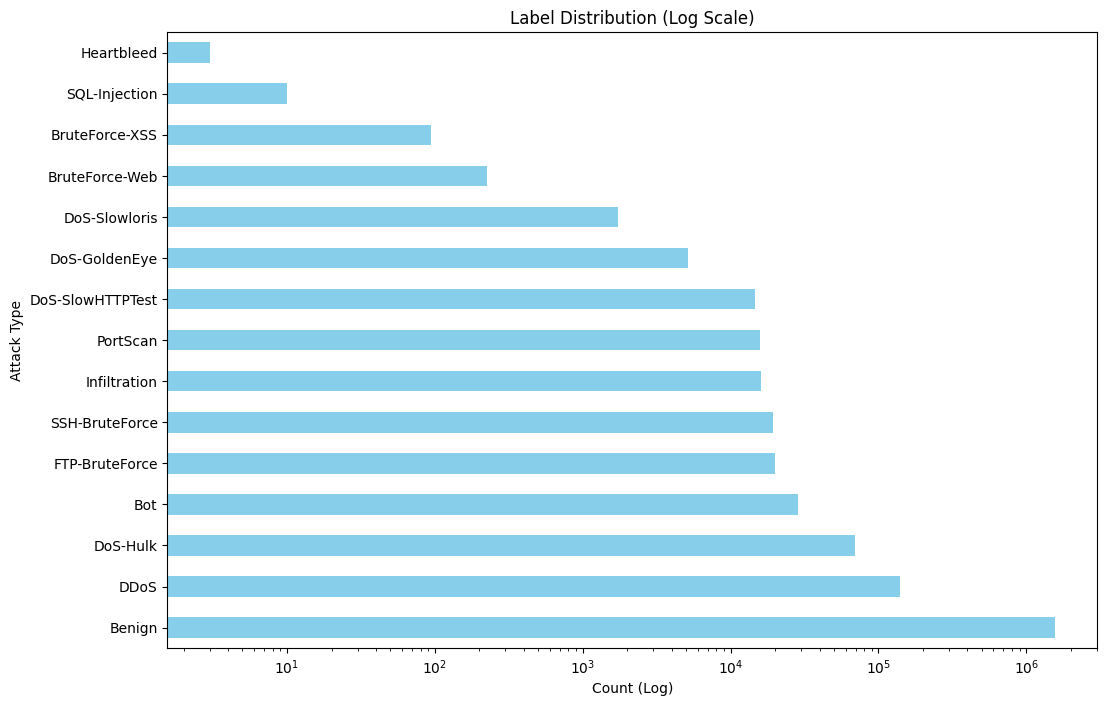

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = df['Label'].value_counts().plot(kind='barh', color='skyblue')
ax.set_xscale('log') plt.title('Label Distribution (Log Scale)')
plt.xlabel('Count (Log)')
plt.ylabel('Attack Type')
plt.show()

In [17]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [18]:
df['Label'] = le.fit_transform(df['Label'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

In [42]:
X = df.drop(columns=['Label'])
y = df['Label']

In [43]:
y.unique()

array([ 0,  9, 14,  8,  6,  7,  5, 10,  2,  3, 13,  4, 12,  1, 11])

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
from sklearn.preprocessing import StandardScaler
print("⚖️ Scaling features...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

⚖️ Scaling features...


In [46]:
print("Training LightGBM Model...")
model = LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    num_class=len(le.classes_),
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

Training LightGBM Model...


In [47]:
model.fit(X_train, y_train)
print(" Training done!")

 Training done!


In [49]:
print(" Evaluating model...")
y_pred = model.predict(X_test)

 Evaluating model...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [50]:
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


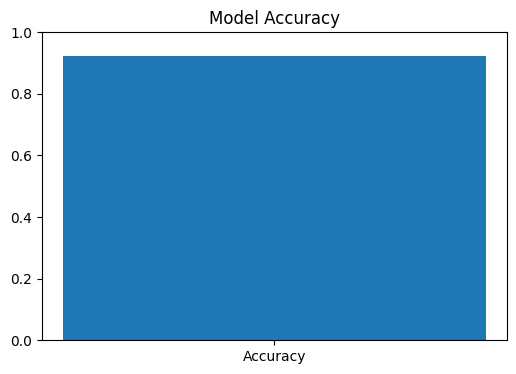

In [51]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.bar(["Accuracy"], [acc])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()

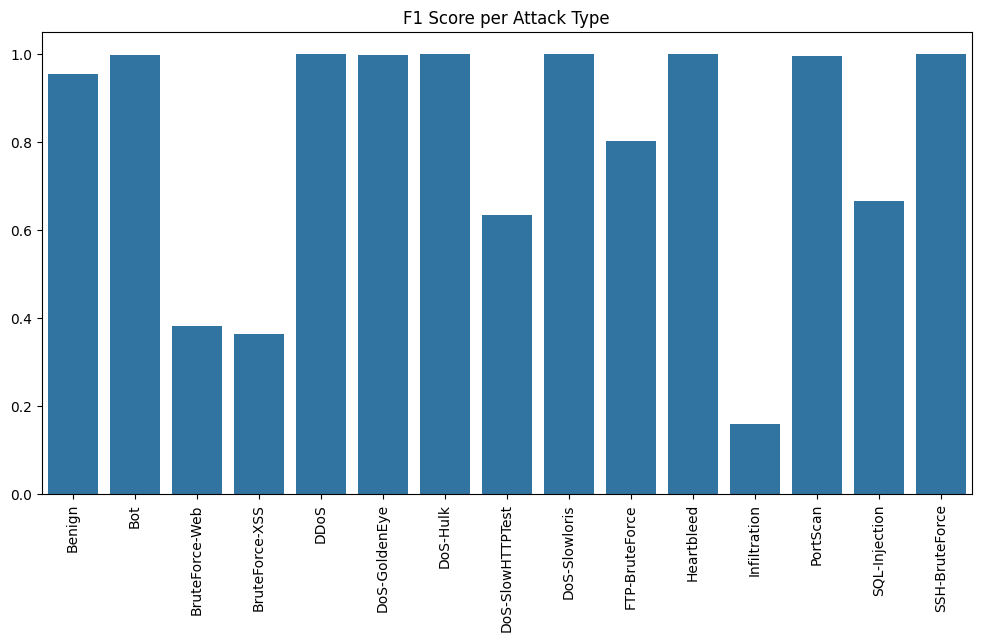

In [52]:
report = classification_report(y_test, y_pred, output_dict=True)

classes = list(le.classes_)
f1_scores = [report[str(i)]['f1-score'] for i in range(len(classes))]

plt.figure(figsize=(12,6))
sns.barplot(x=classes, y=f1_scores)
plt.xticks(rotation=90)
plt.title("F1 Score per Attack Type")
plt.show()

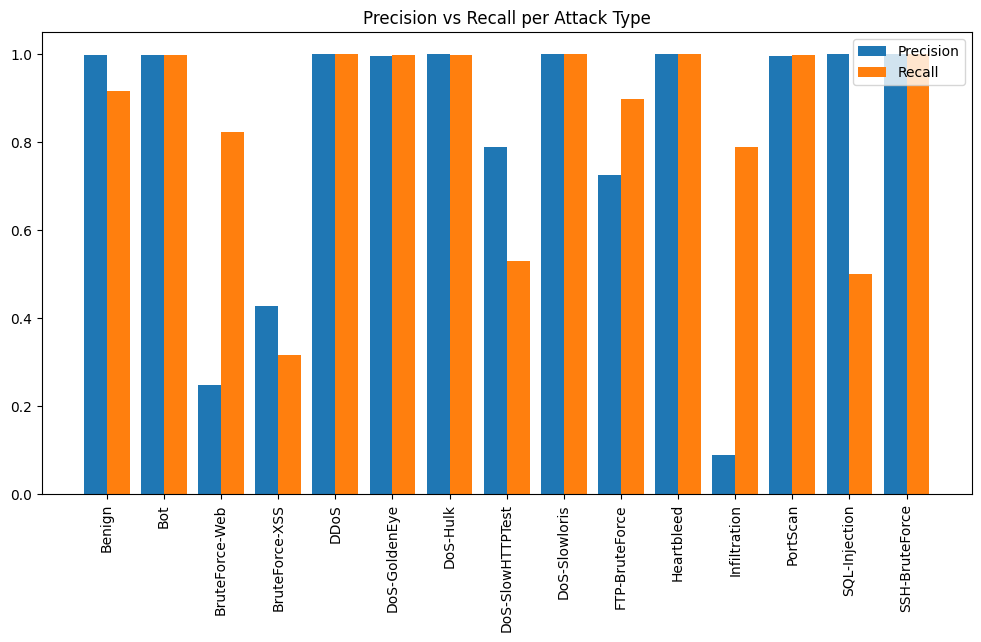

In [53]:
precision = [report[str(i)]['precision'] for i in range(len(classes))]
recall = [report[str(i)]['recall'] for i in range(len(classes))]

x = np.arange(len(classes))

plt.figure(figsize=(12,6))
plt.bar(x - 0.2, precision, 0.4, label="Precision")
plt.bar(x + 0.2, recall, 0.4, label="Recall")

plt.xticks(x, classes, rotation=90)
plt.legend()
plt.title("Precision vs Recall per Attack Type")
plt.show()

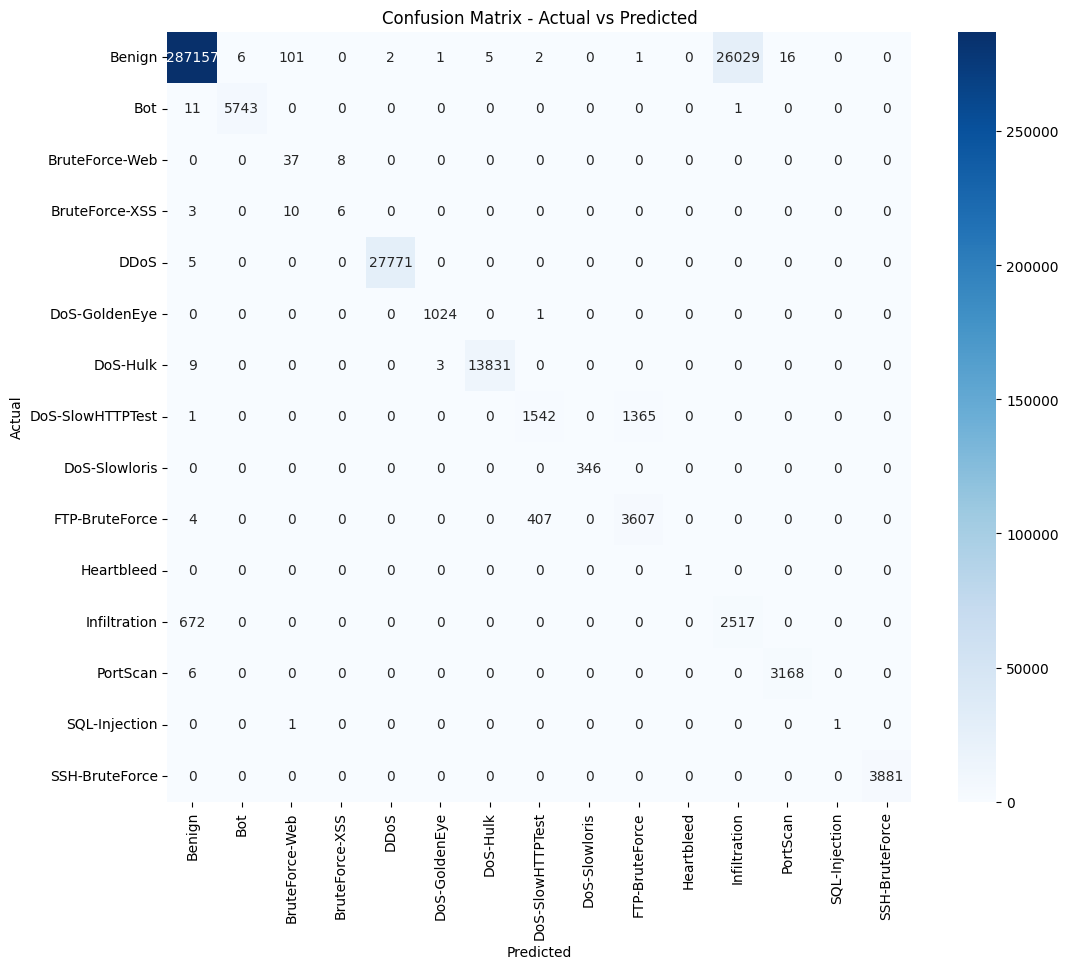

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_, 
            cmap='Blues')
plt.title('Confusion Matrix - Actual vs Predicted')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

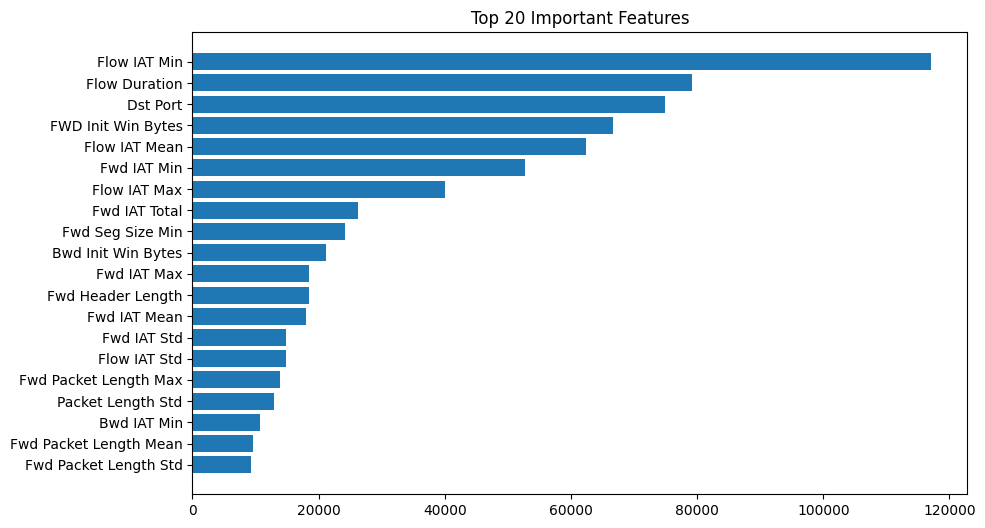

In [54]:
importances = model.feature_importances_
features = X.columns

idx = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(features[idx], importances[idx])
plt.title("Top 20 Important Features")
plt.show()